In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline 
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler  
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,r2_score,root_mean_squared_error

In [2]:
df=pd.read_csv('Walmart_Sales.csv')

In [3]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [4]:
df.shape

(6435, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [6]:
df.corr(numeric_only=True)

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
Store,1.000000e+00,-0.335332,-4.386841e-16,-0.022659,0.060023,-0.209492,0.223531
Weekly_Sales,-3.353320e-01,1.000000,3.689097e-02,-0.063810,0.009464,-0.072634,-0.106176
Holiday_Flag,-4.386841e-16,0.036891,1.000000e+00,-0.155091,-0.078347,-0.002162,0.010960
Temperature,-2.265908e-02,-0.063810,-1.550913e-01,1.000000,0.144982,0.176888,0.101158
Fuel_Price,6.002295e-02,0.009464,-7.834652e-02,0.144982,1.000000,-0.170642,-0.034684
CPI,-2.094919e-01,-0.072634,-2.162091e-03,0.176888,-0.170642,1.000000,-0.302020
Unemployment,2.235313e-01,-0.106176,1.096028e-02,0.101158,-0.034684,-0.302020,1.000000


In [7]:
df['Date']=pd.to_datetime(df['Date'],dayfirst=True)
df['Year']=df['Date'].dt.year
df['Month']=df['Date'].dt.month
df['Week']=df['Date'].dt.isocalendar().week.astype(int)

In [8]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,6
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,7
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,8
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,9


In [9]:
df=df.drop('Date',axis=1)

In [10]:
X=df.drop(columns=['Weekly_Sales'])
y=df['Weekly_Sales']

In [11]:
Xtrain,Xtest,ytrain,ytest=train_test_split(X,y,train_size=0.8,random_state=42)

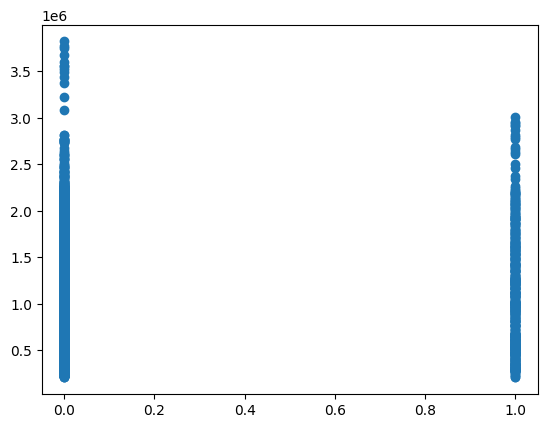

In [12]:
plt.scatter(df['Holiday_Flag'],y)
plt.show()

In [13]:
X.describe()

,Store,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week
count,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,0.069930,60.663782,3.358607,171.578394,7.999151,2010.965035,6.447552,25.818182
std,12.988182,0.255049,18.444933,0.459020,39.356712,1.875885,0.797019,3.238308,14.129201
min,1.000000,0.000000,-2.060000,2.472000,126.064000,3.879000,2010.000000,1.000000,1.000000
25%,12.000000,0.000000,47.460000,2.933000,131.735000,6.891000,2010.000000,4.000000,14.000000
50%,23.000000,0.000000,62.670000,3.445000,182.616521,7.874000,2011.000000,6.000000,26.000000
75%,34.000000,0.000000,74.940000,3.735000,212.743293,8.622000,2012.000000,9.000000,38.000000
max,45.000000,1.000000,100.140000,4.468000,227.232807,14.313000,2012.000000,12.000000,52.000000


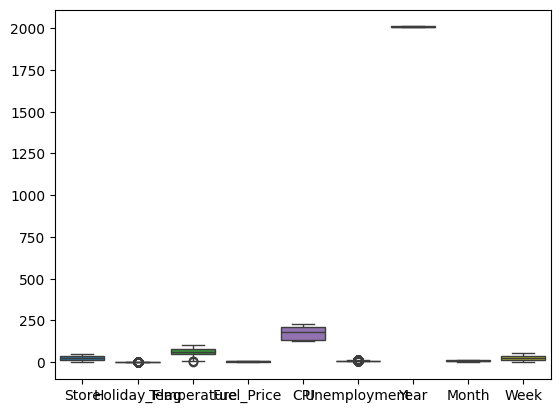

In [14]:
sns.boxplot(X)
plt.show()

In [15]:
for col in X:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1

    lower=Q1 - 1.5 * IQR
    upper=Q3 + 1.5 * IQR

    outlier=df[(df[col]<lower)|(df[col]>upper)]

    print('\n',col )
    print('lower: ',lower)
    print('upper: ',upper)
    print('outlier: ',len(outlier))


 Store
lower:  -21.0
upper:  67.0
outlier:  0

 Holiday_Flag
lower:  0.0
upper:  0.0
outlier:  450

 Temperature
lower:  6.240000000000002
upper:  116.16
outlier:  3

 Fuel_Price
lower:  1.7299999999999998
upper:  4.938
outlier:  0

 CPI
lower:  10.222559825000019
upper:  334.255733625
outlier:  0

 Unemployment
lower:  4.2945
upper:  11.218499999999999
outlier:  481

 Year
lower:  2007.0
upper:  2015.0
outlier:  0

 Month
lower:  -3.5
upper:  16.5
outlier:  0

 Week
lower:  -22.0
upper:  74.0
outlier:  0


In [16]:
num_cols=X.select_dtypes(include='number').columns

In [17]:
preprocessor=ColumnTransformer(
    transformers=[
        ('scaling',RobustScaler(),num_cols)  
    ],
    remainder='passthrough'
)

In [ ]:

main_pipe=Pipeline(
    steps=[('preprocess',preprocessor),
           ('pca',PCA(n_components=0.9)),
           ('knn',KNeighborsRegressor())]     
)

In [19]:
main_pipe.fit(Xtrain,ytrain)

,steps,"[('preprocess', ...), ('pca', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('scaling', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [20]:
ytrain_pred=main_pipe.predict(Xtrain)
ytest_pred=main_pipe.predict(Xtest)

In [21]:
print('Training :')
print('r2_score: ',r2_score(ytrain,ytrain_pred))
print('MAE: ',mean_absolute_error(ytrain,ytrain_pred))
print('RMSE: ',root_mean_squared_error(ytrain,ytrain_pred))

Training :
r2_score:  0.7750586258595612
MAE:  175264.87961849262
RMSE:  267250.3687328433


In [22]:
print('Testing :')
print('r2_score: ',r2_score(ytest,ytest_pred))
print('MAE: ',mean_absolute_error(ytest,ytest_pred))
print('RMSE: ',root_mean_squared_error(ytest,ytest_pred))

Testing :
r2_score:  0.604877582474624
MAE:  241577.82746231547
RMSE:  356777.9286824168


In [23]:
model=DecisionTreeRegressor(random_state=42)
model.fit(Xtrain,ytrain)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [24]:
DT_pipe=Pipeline(
    steps=[('preprocess',preprocessor),
           ('pca',PCA(n_components=0.9)),
           ('model',DecisionTreeRegressor(random_state=42))]
)

In [25]:
from sklearn.model_selection import GridSearchCV
grid_cv=GridSearchCV(
    estimator=DT_pipe,
    param_grid=[{
        'model__criterion':['squared_error', 'absolute_error'],
        'model__splitter':['best', 'random'],
        'model__max_depth':[1,2,5,10,20],
        'model__min_samples_split':[2,4,6,10],
        'model__min_samples_leaf':[1,3,4,5]
    }],
    cv=5, n_jobs=-1
)

In [26]:
grid_cv.fit(Xtrain,ytrain)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"[{'model__criterion': ['squared_error', 'absolute_error'], 'model__max_depth': [1, 2, ...], 'model__min_samples_leaf': [1, 3, ...], 'model__min_samples_split': [2, 4, ...], ...}]"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('scaling', ...)]"


In [27]:
grid_cv.best_estimator_

,steps,"[('preprocess', ...), ('pca', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('scaling', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [28]:
grid_cv.best_params_

{'model__criterion': 'squared_error',
 'model__max_depth': 20,
 'model__min_samples_leaf': 5,
 'model__min_samples_split': 2,
 'model__splitter': 'best'}

In [29]:
tree_train_pred=grid_cv.predict(Xtrain)
tree_test_pred=grid_cv.predict(Xtest)

In [30]:
print('Training :')
print('r2_score: ',r2_score(ytrain,tree_train_pred))
print('MAE: ',mean_absolute_error(ytrain,tree_train_pred))
print('RMSE: ',root_mean_squared_error(ytrain,tree_train_pred))

Training :
r2_score:  0.8604075867248441
MAE:  120839.8360025333
RMSE:  210530.27069031564


In [31]:
print('Testing :')
print('r2_score: ',r2_score(ytest,tree_test_pred))
print('MAE: ',mean_absolute_error(ytest,tree_test_pred))
print('RMSE: ',root_mean_squared_error(ytest,tree_test_pred))

Testing :
r2_score:  0.5638139224799293
MAE:  227038.41956946862
RMSE:  374859.08806213323


### Random Forest Regressor

In [32]:
RF_pipe=Pipeline(
    steps=[('preprocess',preprocessor),
           ('pca',PCA()),
           ('model',RandomForestRegressor(random_state=42))]
)

In [34]:
grid_cv_R = GridSearchCV(
    estimator=RF_pipe,
    param_grid={
        'pca__n_components': [2, 3, 4, 5],
        'model__n_estimators': [100],
        'model__max_depth': [10, 20],
        'model__min_samples_split': [2, 5],
        'model__min_samples_leaf': [1, 3]
    },
    cv=3,
    n_jobs=-1
)

In [35]:
grid_cv_R.fit(Xtrain,ytrain)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [10, 20], 'model__min_samples_leaf': [1, 3], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100], ...}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('scaling', ...)]"


In [36]:
grid_cv_R.best_params_

{'model__max_depth': 20,
 'model__min_samples_leaf': 1,
 'model__min_samples_split': 2,
 'model__n_estimators': 100,
 'pca__n_components': 5}

In [37]:
RF_train_pred=grid_cv_R.predict(Xtrain)
RF_test_pred=grid_cv_R.predict(Xtest)

In [38]:
print('Training :')
print('r2_score: ',r2_score(ytrain,RF_train_pred))
print('MAE: ',mean_absolute_error(ytrain,RF_train_pred))
print('RMSE: ',root_mean_squared_error(ytrain,RF_train_pred))

Training :
r2_score:  0.9628349874983959
MAE:  71138.12971879383
RMSE:  108630.25093875673


In [39]:
print('Testing :')
print('r2_score: ',r2_score(ytest,RF_test_pred)) 
print('MAE: ',mean_absolute_error(ytest,RF_test_pred))
print('RMSE: ',root_mean_squared_error(ytest,RF_test_pred))

Testing :
r2_score:  0.7502641435491452
MAE:  185096.29272610476
RMSE:  283643.3431412725


In [40]:
XGB_pipe = Pipeline(
    steps=[
        ('preprocess',preprocessor),
        ('model',XGBRegressor(random_state=42,objective='reg:squarederror'))
    ]
)

In [41]:
grid_cv_XGB = GridSearchCV(
    estimator=XGB_pipe,
    param_grid={
        'model__n_estimators': [100, 200],
        'model__max_depth': [3, 5, 7],
        'model__learning_rate': [0.05, 0.1],
        'model__subsample': [0.8, 1.0],
        'model__colsample_bytree': [0.8, 1.0]
    },
    cv=3,
    scoring='r2',
    n_jobs=-1
)

In [42]:
grid_cv_XGB.fit(Xtrain, ytrain)

,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'model__colsample_bytree': [0.8, 1.0], 'model__learning_rate': [0.05, 0.1], 'model__max_depth': [3, 5, ...], 'model__n_estimators': [100, 200], ...}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('scaling', ...)]"


In [43]:
print("Best Parameters:")
print(grid_cv_XGB.best_params_)

Best Parameters:
{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200, 'model__subsample': 0.8}


In [44]:
print("Best Estimator:")
print(grid_cv_XGB.best_estimator_)

Best Estimator:
Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scaling', RobustScaler(),
                                                  Index(['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI',
       'Unemployment', 'Year', 'Month', 'Week'],
      dtype='object'))])),
                ('model',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsam...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=No

In [ ]:
XGB_train_pred=grid_cv_XGB.predict(Xtrain)
XGB_test_pred=grid_cv_XGB.predict(Xtest)

In [ ]:
print("Training:")
print("R2 Score: ",r2_score(ytrain,XGB_train_pred))
print("MAE: ",mean_absolute_error(ytrain,XGB_train_pred))
print("RMSE: ",root_mean_squared_error(ytrain,XGB_train_pred))

Training:
R2 Score: 0.9911019805614361
MAE: 37244.824889155985
RMSE: 53153.310226508635


In [ ]:
print("\nTesting:")
print("R2 Score: ",r2_score(ytest,XGB_test_pred))
print("MAE: ",mean_absolute_error(ytest,XGB_test_pred))
print("RMSE: ",root_mean_squared_error(ytest,XGB_test_pred))


Testing:
R2 Score: 0.9748722720142753
MAE: 54974.64519170067
RMSE: 89972.28611898236
